# Do syllables predict GLM-HMM state transitions?

Three questions, one section each:

1. **How predictable are transitions?** Held-out skill of a task-history baseline, of syllables alone, and of both, as a function of how many trials back the model looks (`LAGS`).
2. **What do they rely on?** Which epochs / lags / syllables carry the prediction (coefficients, grouped permutation importance), next to a model-free picture of syllable use around transitions.
3. **Does the mapping change along LD1?** Per-mouse gain vs LD1, an LD1-interaction model, and train-on-one-LD1-bin / test-on-another transfer.

Data, target and design choices are documented in `tp_data.py`; models and tests in `tp_models.py`. The essentials:

* **Target = hazard.** Conditional on the state at t-1, does the animal leave it at t (or within `HORIZON` trials)? `disengage` = leaving the engaged state, `reengage` = leaving a disengaged one. Conditioning keeps the model from "predicting transitions" by merely recognising the state.
* **No peeking.** Trial t contributes only its pre-stimulus epochs (Pre-quiescence, Quiescence); everything else comes from t-1 … t-`LAG`. Trial t's Choice / ITI contain the choice that defines the state at t.
* **The baseline matters.** Syllables carry task history (rewards are followed by licking), so the question is what syllables add *over* the task history: `full` vs `base`.
* **Session-centred syllables** (`CENTER='session'`): LD1 is built from session-level syllable usage, so only trial-to-trial fluctuations enter here.
* **Mice are held out** in every CV fold (`CV='mouse'`).

In [1]:
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_p = pathlib.Path.cwd().resolve()
while not (_p / 'paper_style.py').exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
sys.path.insert(0, str(_p / 'GLM-HMM' / 'transition_prediction'))
import paper_style as ps
import tp_data as td
import tp_models as tm
ps.use('paper')
pd.set_option('display.width', 160)

paper_style: paper mode, spines=lb, font 8 pt, panels 3.4x2.4 in, save 400 dpi


## Parameters

In [2]:
# --- states ---------------------------------------------------------------------------------
STATE_SOURCE = 'k2_original'   # 'k2_original' (load_states.ipynb's fit) or 'all_k' (refits)
K = 2                          # only used with 'all_k' (2, 3 or 4)
HORIZON = 1                    # target = leave the state within the next HORIZON trials

# --- features -------------------------------------------------------------------------------
FEATURE_SET = 'decomposed'     # 'decomposed' (8 paw + whisk + lick per epoch) or 'joint' (32 codes)
EPOCHS = td.EPOCHS             # which epochs of past trials to use
CURRENT_PRESTIM = True         # include trial t's Pre-quiescence + Quiescence
LAG_MODE = 'stack'             # 'stack' = separate weights per lag; 'mean' = average lags 1..L
CENTER = 'session'             # 'session' or None

# --- lag sweep and analysis -----------------------------------------------------------------
LAGS = [1, 2, 3, 5, 8]         # how many trials back
SWEEP_TARGETS = ['disengage', 'reengage']
TARGET = 'disengage'           # target for sections 3 and 4
LAG = 3                        # lag for sections 3 and 4 (revisit after the sweep)
CV = 'mouse'                   # 'mouse' or 'session'
N_SPLITS = 5
N_LD1_BINS = 3

DESIGN_KW = dict(epochs=EPOCHS, current_prestim=CURRENT_PRESTIM, lag_mode=LAG_MODE, center=CENTER)

## 1. Data

In [3]:
df = td.build_trial_table(STATE_SOURCE, K, FEATURE_SET, HORIZON)
print(f"{df['eid'].nunique()} sessions, {df['mouse_name'].nunique()} mice, {len(df)} trials "
      f"(states x syllables x LD1)")
align = td.check_alignment(df)
print(f"syllable/state alignment: min {align.min():.3f} over sessions")
pd.DataFrame({t: dict(trials_at_risk=int(df[t].notna().sum()), events=int(df[t].sum()),
                      rate=df[t].mean()) for t in td.TARGETS}).T

244 sessions, 56 mice, 152377 trials (states x syllables x LD1)


syllable/state alignment: min 1.000 over sessions


,trials_at_risk,events,rate
disengage,132140.0,2466.0,0.018662
reengage,19993.0,2476.0,0.123843
any,152133.0,4942.0,0.032485


In [4]:
ev = df.groupby(['mouse_name', 'eid'])[['disengage', 'reengage']].sum()
print('events per session:'); print(ev.describe().round(1).T)
print('\nevents per mouse:'); print(ev.groupby('mouse_name').sum().describe().round(1).T)

events per session:
           count  mean  std  min  25%  50%   75%   max
disengage  244.0  10.1  8.3  0.0  4.0  8.0  13.0  49.0
reengage   244.0  10.1  8.4  0.0  4.0  8.0  14.0  50.0

events per mouse:
           count  mean   std  min   25%   50%   75%    max
disengage   56.0  44.0  42.4  1.0  19.8  29.0  58.5  256.0
reengage    56.0  44.2  43.0  2.0  18.8  29.0  60.0  255.0


## 2. How predictable are transitions, and how far back does it help to look?

`ll_skill` = 1 − held-out log loss / log loss of the base rate (0 = chance). The difference `full − base` is what syllables add beyond task history.

In [5]:
sweep = {}
for target in SWEEP_TARGETS:
    print(f'--- {target}')
    sweep[target] = tm.lag_sweep(df, target, LAGS, cv=CV, n_splits=N_SPLITS, **DESIGN_KW)
sweep_df = pd.concat([s.assign(target=t) for t, s in sweep.items()], ignore_index=True)
sweep_df.to_csv(td.HERE / f'results_lag_sweep_{STATE_SOURCE}_K{K}_h{HORIZON}.csv', index=False)
sweep_df.pivot_table(index=['target', 'lag'], columns='model', values=['ll_skill', 'auc']).round(4)

--- disengage


lag 1: base skill=0.0153 auc=0.616, syll skill=0.0060 auc=0.561, full skill=0.0199 auc=0.631


lag 2: base skill=0.0161 auc=0.616, syll skill=0.0059 auc=0.560, full skill=0.0202 auc=0.630


lag 3: base skill=0.0165 auc=0.618, syll skill=0.0054 auc=0.561, full skill=0.0193 auc=0.627


lag 5: base skill=0.0166 auc=0.618, syll skill=0.0057 auc=0.558, full skill=0.0183 auc=0.622


...

lag 2: base skill=0.1600 auc=0.777, syll skill=0.0372 auc=0.638, full skill=0.1554 auc=0.772


lag 3: base skill=0.1648 auc=0.781, syll skill=0.0393 auc=0.640, full skill=0.1592 auc=0.775


lag 5: base skill=0.1602 auc=0.777, syll skill=0.0357 auc=0.626, full skill=0.1458 auc=0.765


lag 8: base skill=0.1566 auc=0.777, syll skill=0.0291 auc=0.622, full skill=0.1315 auc=0.758


auc                 ll_skill                
model            base    full    syll     base    full    syll
target    lag                                                 
disengage 1    0.6157  0.6307  0.5608   0.0153  0.0199  0.0060
          2    0.6162  0.6301  0.5601   0.0161  0.0202  0.0059
          3    0.6177  0.6270  0.5608   0.0165  0.0193  0.0054
          5    0.6177  0.6216  0.5576   0.0166  0.0183  0.0057
          8    0.6159  0.6188  0.5612   0.0161  0.0175  0.0062
reengage  1    0.7670  0.7650  0.6350   0.1526  0.1519  0.0369
          2    0.7772  0.7725  0.6378   0.1600  0.1554  0.0372
          3    0.7810  0.7745  0.6398   0.1648  0.1592  0.0393
          5    0.7773  0.7651  0.6258   0.1602  0.1458  0.0357
          8    0.7771  0.7581  0.6224   0.1566  0.1315  0.0291

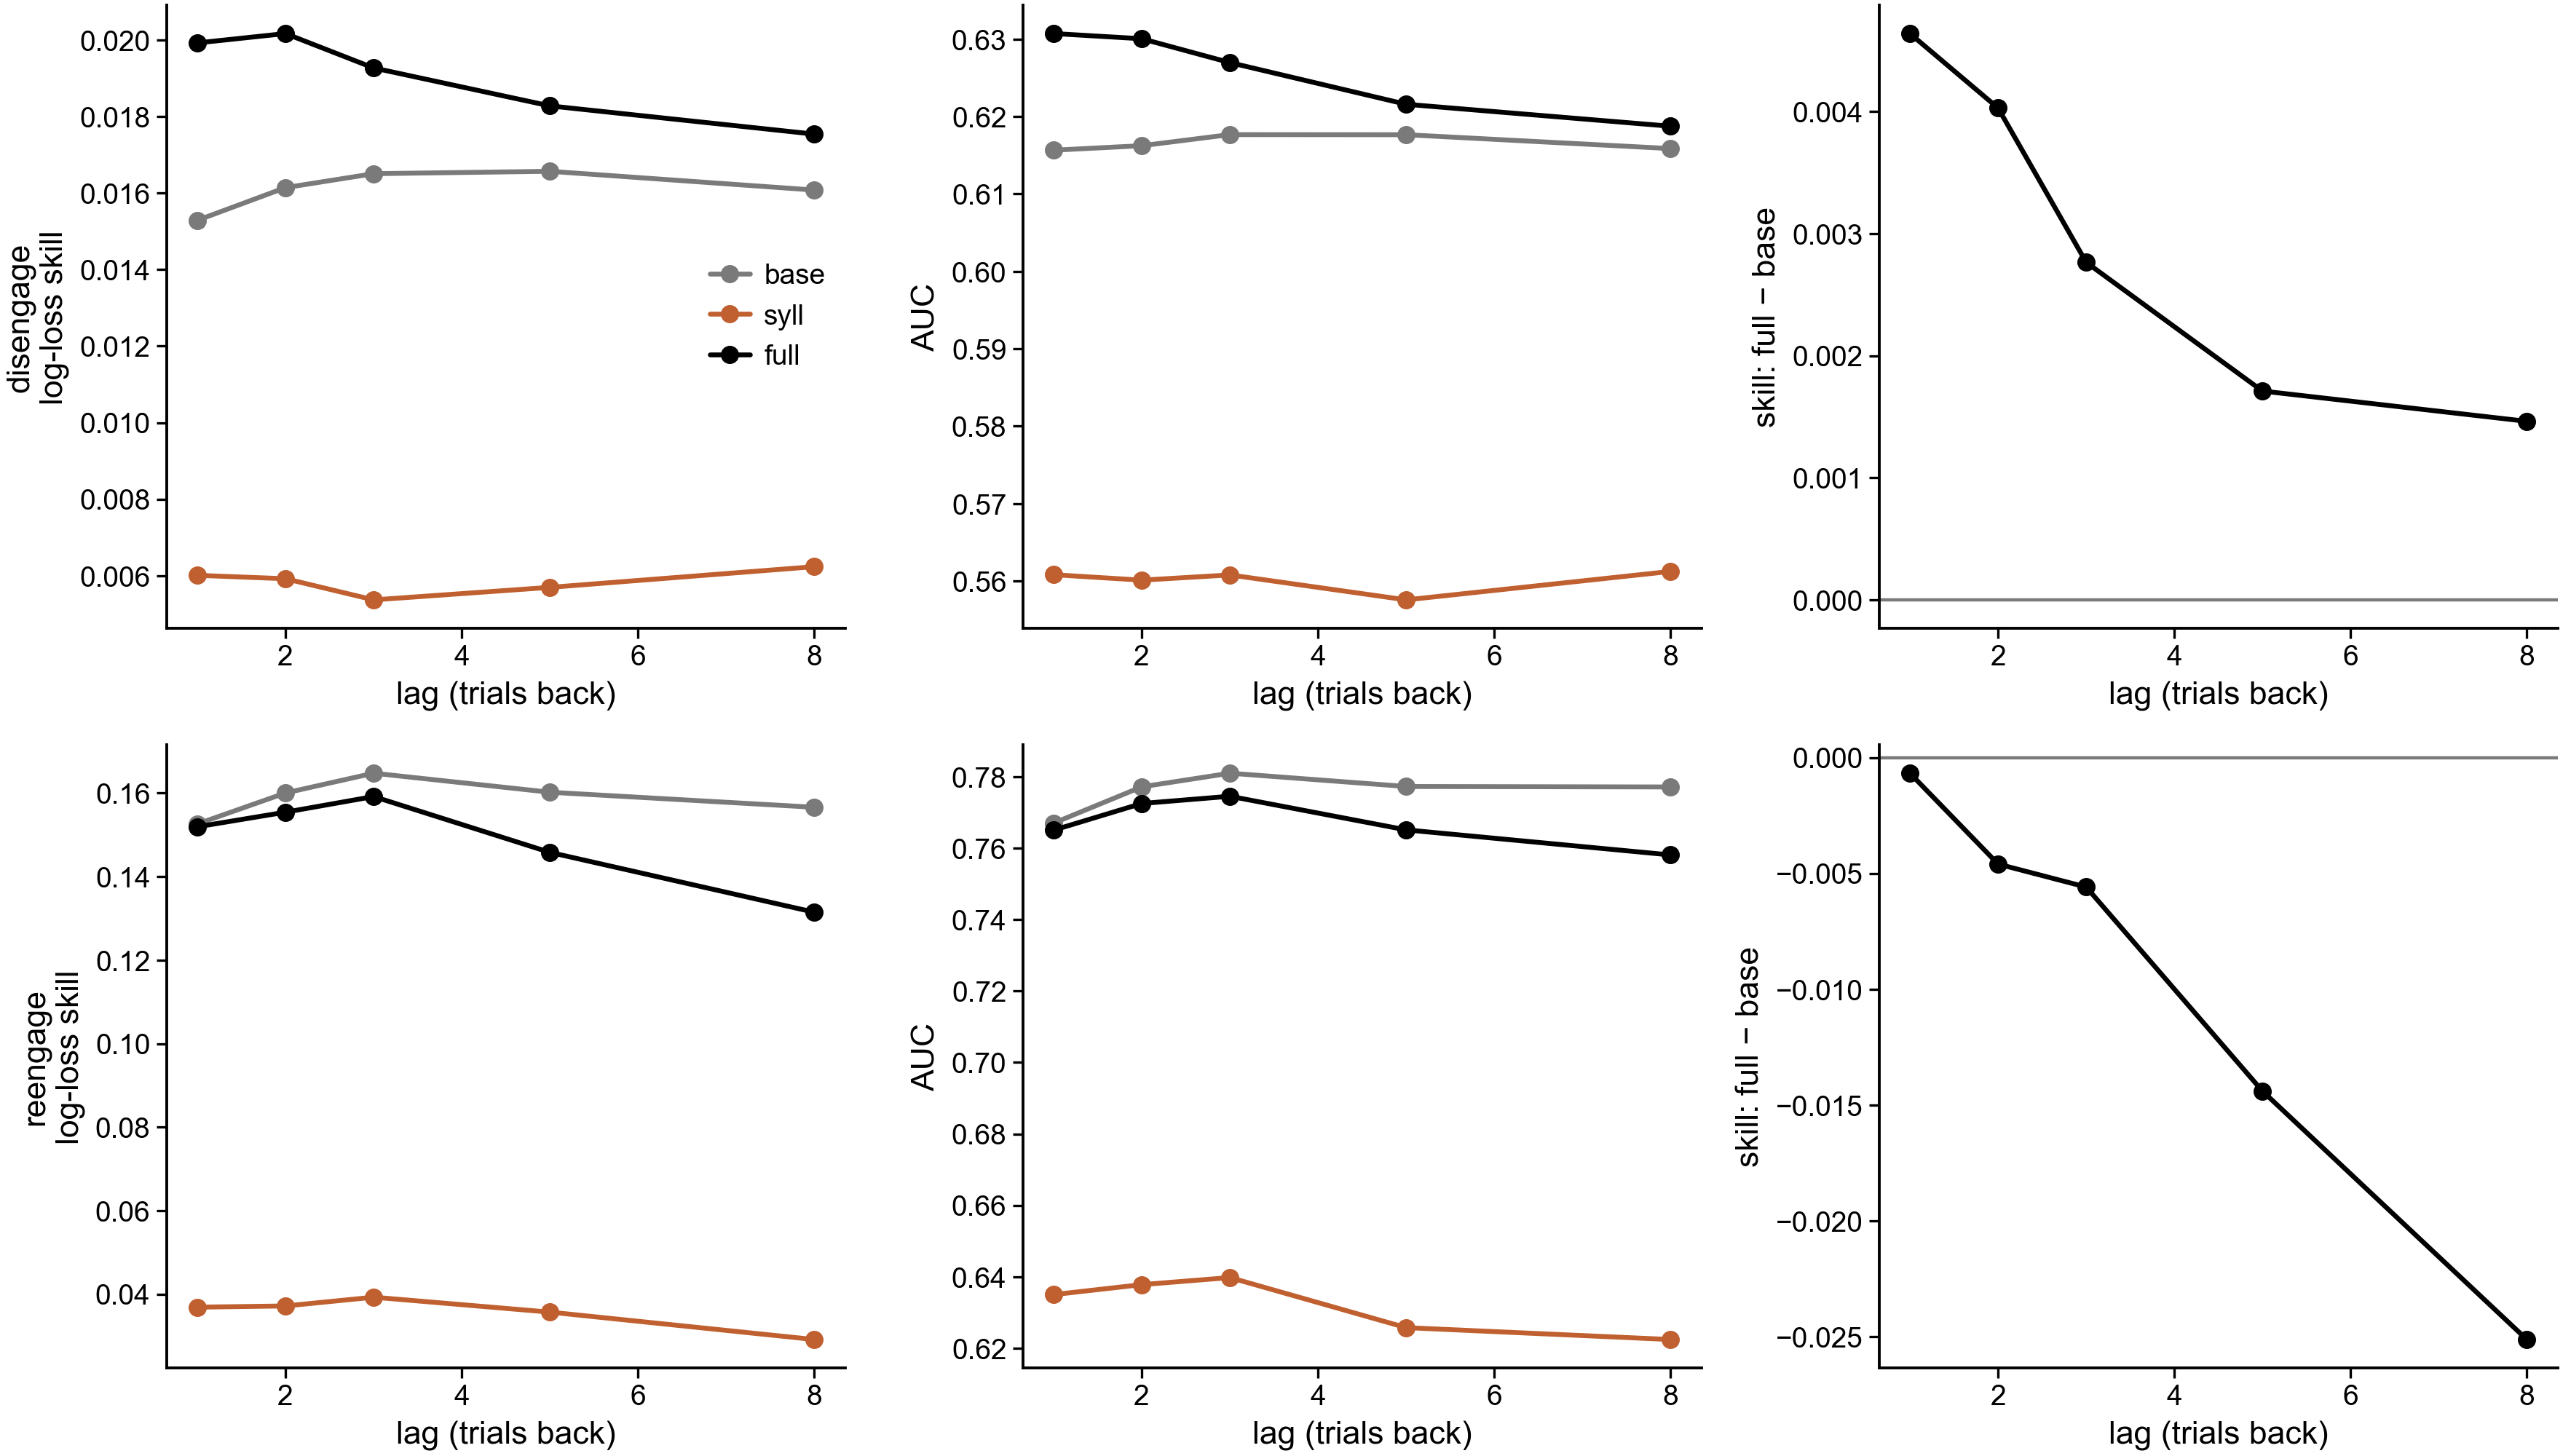

In [6]:
colors = {'base': ps.NEUTRAL, 'syll': '#c06030', 'full': 'k'}
fig, axes = plt.subplots(len(SWEEP_TARGETS), 3, figsize=(9, 2.6 * len(SWEEP_TARGETS)), squeeze=False)
for row, target in enumerate(SWEEP_TARGETS):
    s = sweep[target]
    for m in ['base', 'syll', 'full']:
        d = s[s['model'] == m]
        axes[row, 0].plot(d['lag'], d['ll_skill'], 'o-', color=colors[m], label=m)
        axes[row, 1].plot(d['lag'], d['auc'], 'o-', color=colors[m], label=m)
    w = s.pivot(index='lag', columns='model', values='ll_skill')
    axes[row, 2].plot(w.index, w['full'] - w['base'], 'o-', color='k')
    axes[row, 2].axhline(0, color=ps.NEUTRAL, lw=0.8)
    axes[row, 0].set_ylabel(f'{target}\nlog-loss skill')
    axes[row, 1].set_ylabel('AUC')
    axes[row, 2].set_ylabel('skill: full − base')
    for ax in axes[row]:
        ax.set_xlabel('lag (trials back)')
axes[0, 0].legend(frameon=False)
fig.tight_layout()
plt.show()

## 3. What does the prediction rely on?

### 3a. Model-free: syllable use around transitions
Session-centred usage on trials around each transition (0 = first trial in the new state), mean ± SEM across mice. Trial 0's Choice and ITI epochs are **after** the choice that defines the new state (e.g. the ITI lick drop on trial 0 is reward omission) — they are shown for orientation but are never model inputs.

2198 events, 56 mice


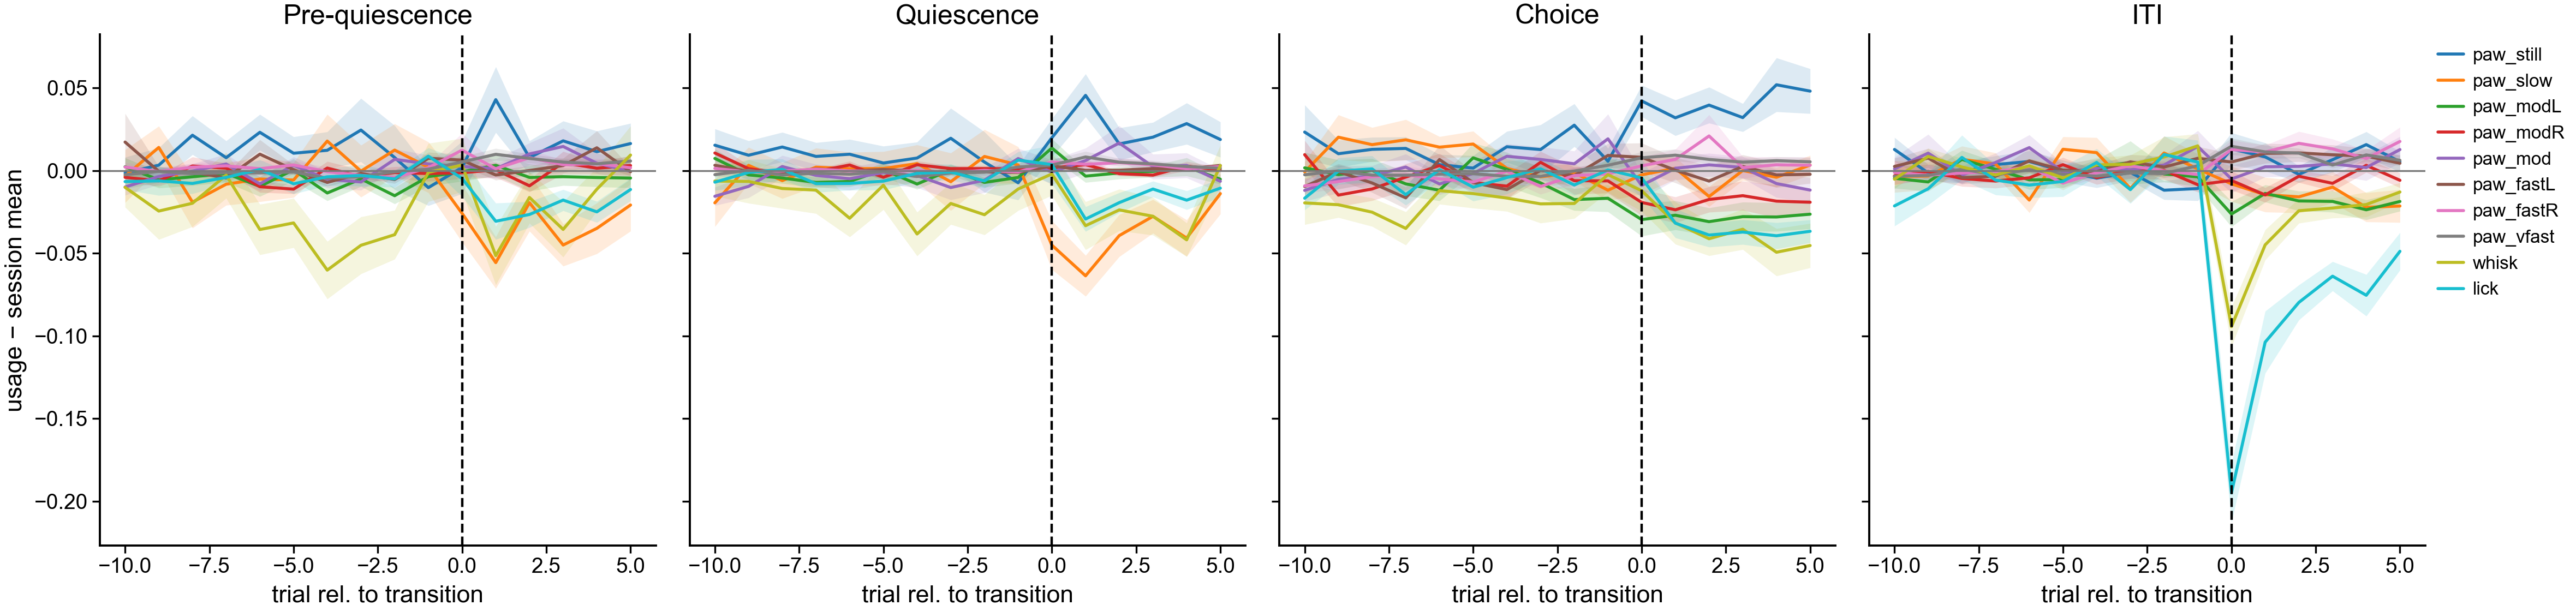

In [7]:
eta = td.event_triggered(df, TARGET, window=(-10, 5))
print(f"{eta.attrs['n_events']} events, {eta.attrs['n_mice']} mice")
feats = [f for f in eta['feature'].unique()]
fig, axes = plt.subplots(1, len(td.EPOCHS), figsize=(12, 3), sharey=True)
cmap = plt.get_cmap('tab10')
for ax, ep in zip(axes, td.EPOCHS):
    for i, f in enumerate(feats):
        d = eta[(eta['epoch'] == ep) & (eta['feature'] == f)]
        ax.plot(d['rel'], d['mean'], color=cmap(i % 10), lw=1, label=f)
        ax.fill_between(d['rel'], d['mean'] - d['sem'], d['mean'] + d['sem'], color=cmap(i % 10), alpha=0.15, lw=0)
    ax.axvline(0, color='k', lw=0.8, ls='--'); ax.axhline(0, color=ps.NEUTRAL, lw=0.6)
    ax.set_title(ep); ax.set_xlabel('trial rel. to transition')
axes[0].set_ylabel('usage − session mean')
axes[-1].legend(frameon=False, fontsize=6, bbox_to_anchor=(1, 1))
fig.tight_layout(); plt.show()

### 3b. Fitted model at `LAG`: coefficients and grouped importance

In [8]:
Xb, Xs, y, meta = td.design(df, TARGET, lag=LAG, **DESIGN_KW)
summary, preds, folds = tm.compare_models(Xb, Xs, y, meta, cv=CV, n_splits=N_SPLITS)
print(f'{TARGET}, lag {LAG}: {y.sum()} events / {len(y)} trials at risk')
summary.round(4)

disengage, lag 3: 2464 events / 131810 trials at risk


,model,n_features,n,events,base_rate,auc,ap,logloss,ll_skill
0,base,11,131810,2464,0.0187,0.6177,0.0267,0.0915,0.0165
1,syll,140,131810,2464,0.0187,0.5608,0.0238,0.0925,0.0054
2,full,151,131810,2464,0.0187,0.6270,0.0290,0.0912,0.0193


baseline terms (standardised):
                   mean     sd  sign_agreement
trial_frac        0.081  0.026             1.0
log_dwell        -0.311  0.054             1.0
reward_t-1        0.067  0.010             1.0
abs_contrast_t-1  0.025  0.015             1.0
congruent_t-1     0.011  0.013             1.0
reward_t-2        0.072  0.017             1.0
abs_contrast_t-2 -0.008  0.015             0.6
congruent_t-2    -0.031  0.014             1.0
reward_t-3       -0.003  0.010             0.6
abs_contrast_t-3  0.036  0.009             1.0
congruent_t-3    -0.039  0.010             1.0


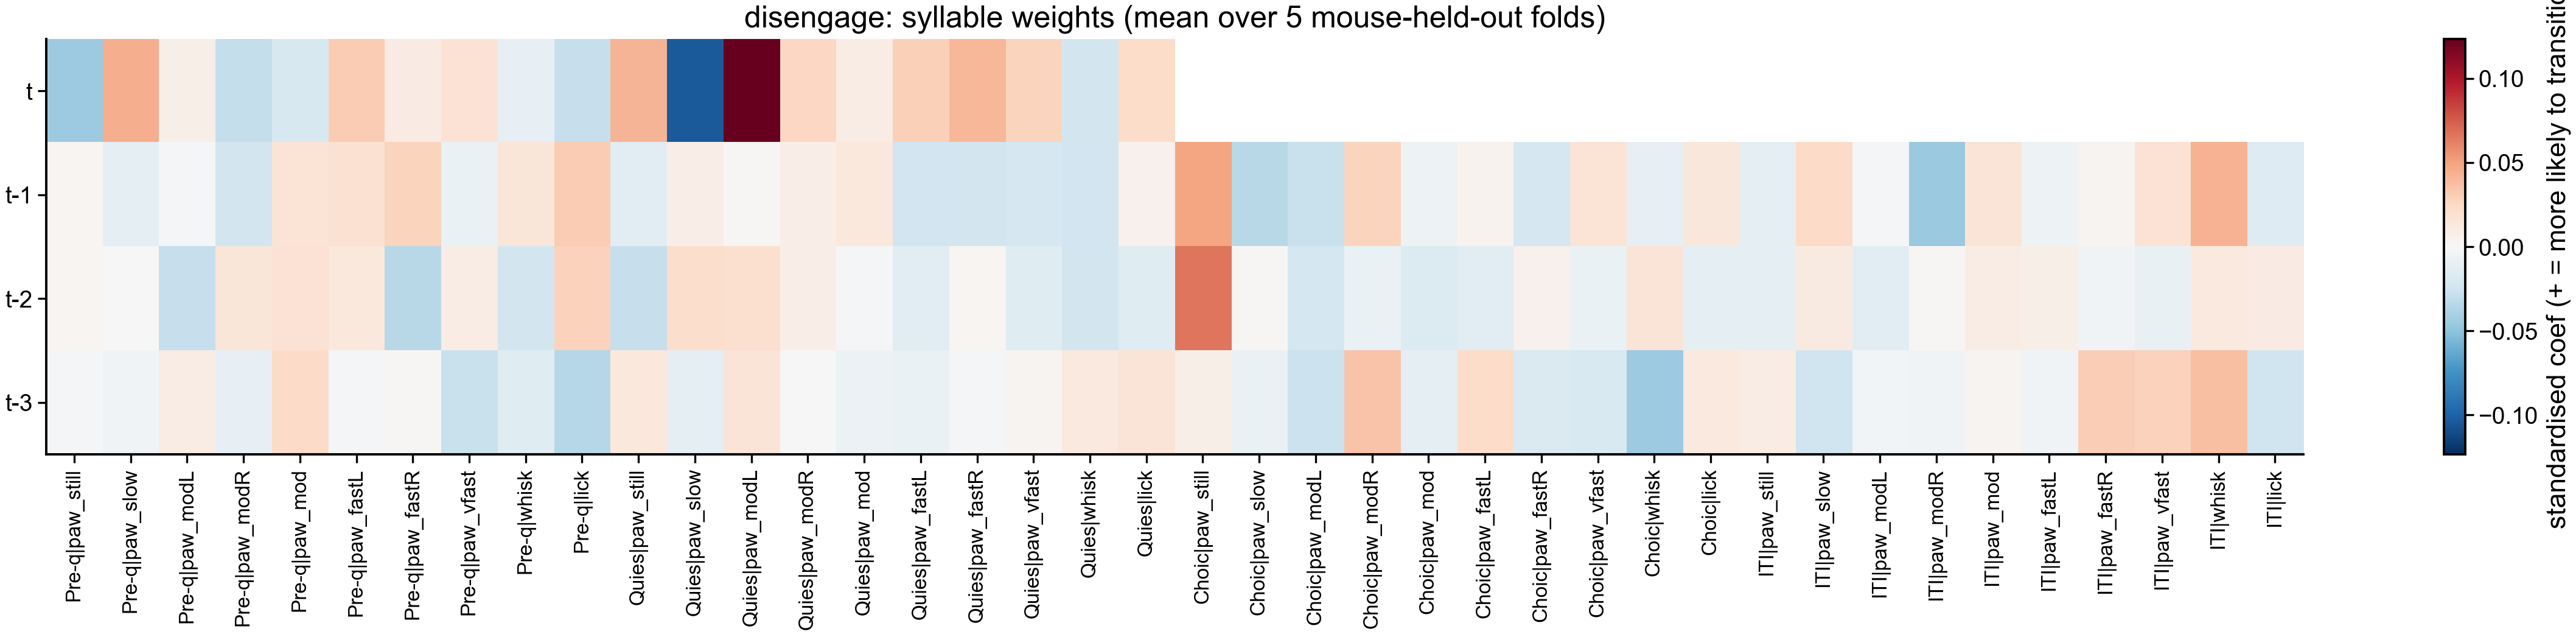

In [9]:
Xfull = pd.concat([Xb, Xs], axis=1)
coef = tm.coefficients(folds['full'], Xfull.columns)
print('baseline terms (standardised):')
print(coef.loc[Xb.columns].round(3))

# syllable coefficients as lag x (epoch, feature) heatmap
cs = coef.loc[Xs.columns, 'mean']
parts = cs.index.str.split('|', expand=True)
H = pd.Series(cs.values, index=pd.MultiIndex.from_tuples(parts, names=['lag', 'epoch', 'feature'])).unstack(['epoch', 'feature'])
order = ['t'] + [f't-{l}' for l in range(1, LAG + 1)] if LAG_MODE == 'stack' else list(H.index)
H = H.reindex(order)
H = H[[c for ep in td.EPOCHS for c in H.columns if c[0] == ep]]
v = np.nanmax(np.abs(H.values))
fig, ax = plt.subplots(figsize=(12, 0.4 * len(H) + 1.2))
im = ax.imshow(H.values, cmap='RdBu_r', vmin=-v, vmax=v, aspect='auto')
ax.set_yticks(range(len(H))); ax.set_yticklabels(H.index)
ax.set_xticks(range(H.shape[1])); ax.set_xticklabels([f'{e[:5]}|{f}' for e, f in H.columns], rotation=90, fontsize=6)
fig.colorbar(im, ax=ax, label='standardised coef (+ = more likely to transition)')
ax.set_title(f'{TARGET}: syllable weights (mean over {len(folds["full"])} mouse-held-out folds)')
fig.tight_layout(); plt.show()

In [10]:
# grouped permutation importance on held-out trials (shuffled within session)
imp = {}
for by in [('lag',), ('epoch',), ('modality',), ('epoch', 'modality'), ('feature',)]:
    groups = td.feature_groups(Xs.columns, by=by)
    groups = {k: v for k, v in groups.items()}
    imp[by] = tm.group_importance(Xfull, y, meta, folds['full'], groups, n_repeats=3)
# baseline terms, for scale
base_groups = {'task: rewards': [c for c in Xb.columns if c.startswith('reward')],
               'task: contrasts': [c for c in Xb.columns if c.startswith('abs_contrast')],
               'task: congruent': [c for c in Xb.columns if c.startswith('congruent')],
               'task: trial_frac': ['trial_frac'], 'task: dwell': ['log_dwell']}
imp['task'] = tm.group_importance(Xfull, y, meta, folds['full'], base_groups, n_repeats=3)
for k, v in imp.items():
    print(f'\n=== by {k}  (Δ held-out log loss × 1e3 when shuffled; > 0 = used)')
    print(v.head(12).round(3).to_string(index=False))


=== by ('lag',)  (Δ held-out log loss × 1e3 when shuffled; > 0 = used)
group  n_cols  d_logloss_x1e3    sd
    t      20           0.989 0.082
  t-1      40           0.165 0.038
  t-3      40           0.085 0.033
  t-2      40           0.032 0.014

=== by ('epoch',)  (Δ held-out log loss × 1e3 when shuffled; > 0 = used)
         group  n_cols  d_logloss_x1e3    sd
    Quiescence      40           0.984 0.082
        Choice      30           0.279 0.006
Pre-quiescence      40           0.258 0.041
           ITI      30           0.015 0.009

=== by ('modality',)  (Δ held-out log loss × 1e3 when shuffled; > 0 = used)
group  n_cols  d_logloss_x1e3    sd
  paw     112           1.272 0.091
whisk      14           0.123 0.021
 lick      14           0.037 0.031

=== by ('epoch', 'modality')  (Δ held-out log loss × 1e3 when shuffled; > 0 = used)
                 group  n_cols  d_logloss_x1e3    sd
      Quiescence / paw      32           0.928 0.032
          Choice / paw      24       

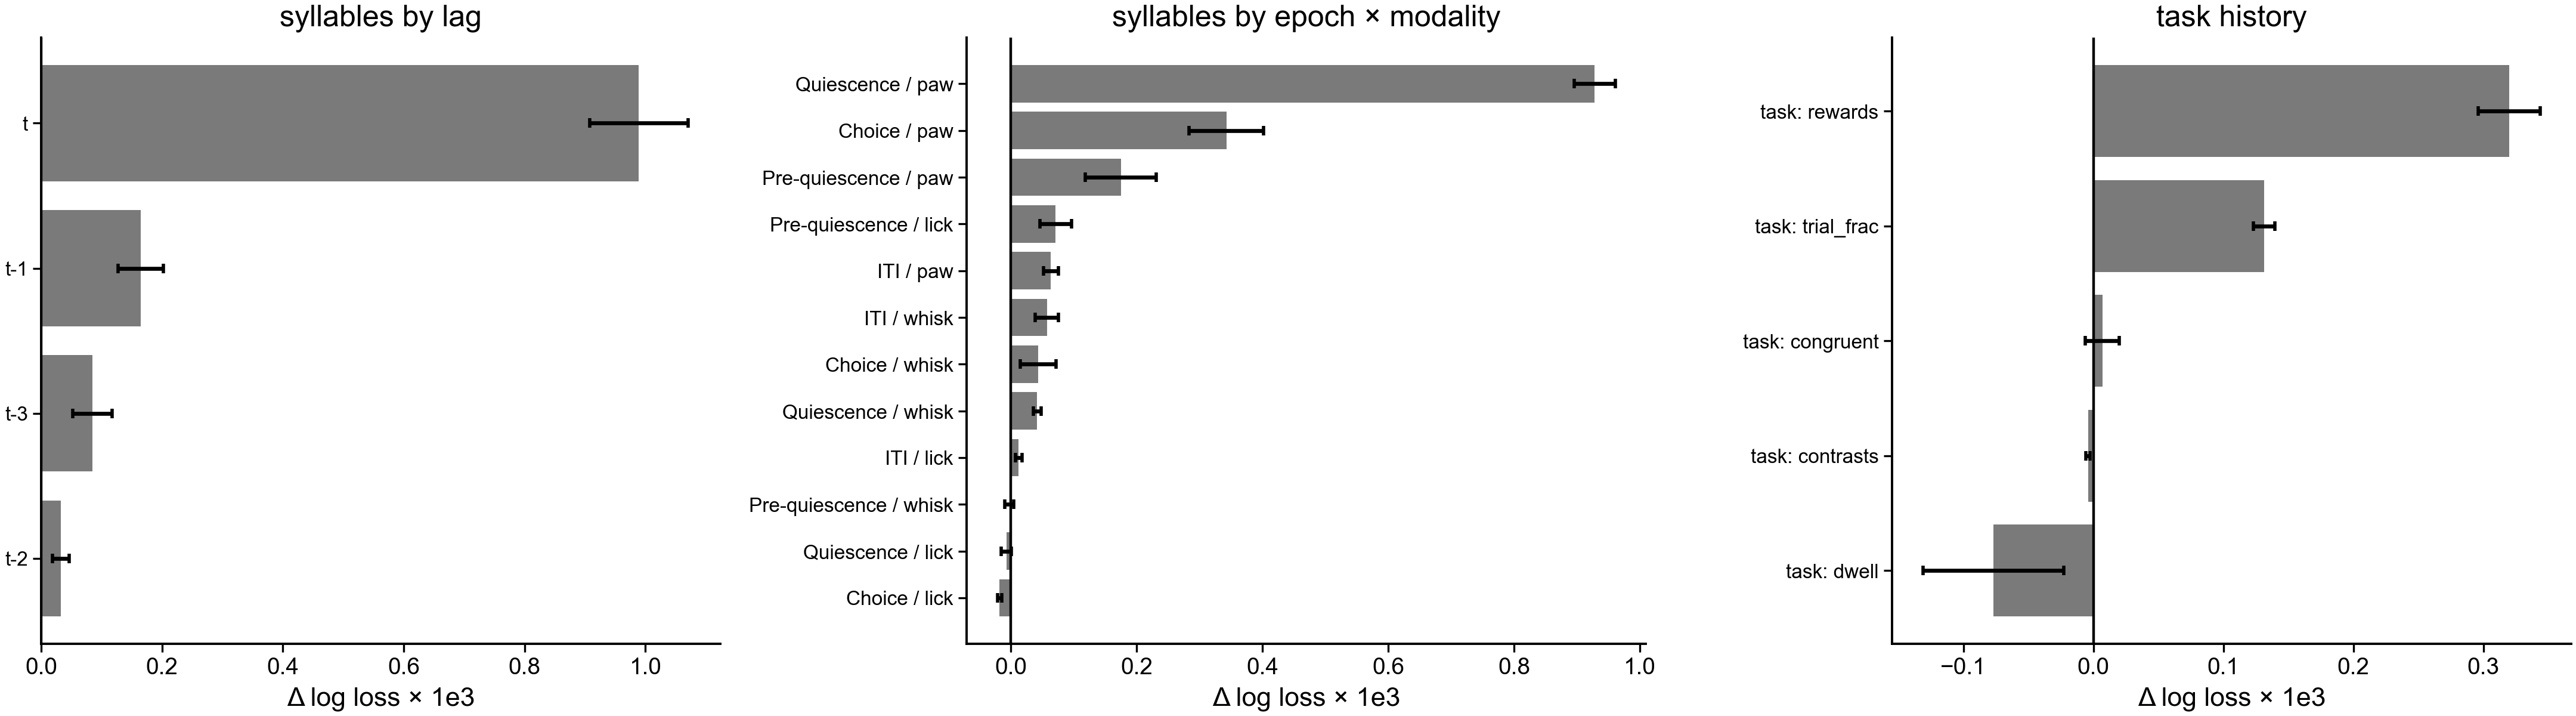

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, key, title in zip(axes, [('lag',), ('epoch', 'modality'), 'task'],
                          ['syllables by lag', 'syllables by epoch × modality', 'task history']):
    d = imp[key].iloc[::-1]
    ax.barh(d['group'], d['d_logloss_x1e3'], xerr=d['sd'], color=ps.NEUTRAL)
    ax.axvline(0, color='k', lw=0.8); ax.set_title(title); ax.set_xlabel('Δ log loss × 1e3')
    ax.tick_params(axis='y', labelsize=6)
fig.tight_layout(); plt.show()

## 4. Does the mapping change along LD1?

Three complementary views, all with mice as the unit:

* **4a. Per-mouse held-out gain** (`full − base` skill and AUC) vs mouse-mean LD1. Asks whether syllables are *more informative* about transitions at one end of LD1.
* **4b. LD1 interaction model**: adds (syllable × LD1) terms; held-out log loss compared per mouse. Asks whether the *weights* change smoothly with LD1.
* **4c. Transfer across LD1 bins**: train on mice in one LD1 tercile, test on another. Asks whether a model from one end of LD1 works at the other.

Caveats: LD1 is lab-confounded (see project notes) — a positive result here should be re-checked with lab-centred LD1 or lab terms. Per-mouse event counts are small (see section 1), so per-mouse scores are noisy.

51 mice with >= 10 events
    metric  n     rho      p
base_skill 51  0.0965 0.5007
full_skill 51 -0.0778 0.5872
gain_skill 51 -0.2428 0.0860
  base_auc 51  0.0326 0.8205
  full_auc 51 -0.1682 0.2380
  gain_auc 51 -0.3009 0.0319


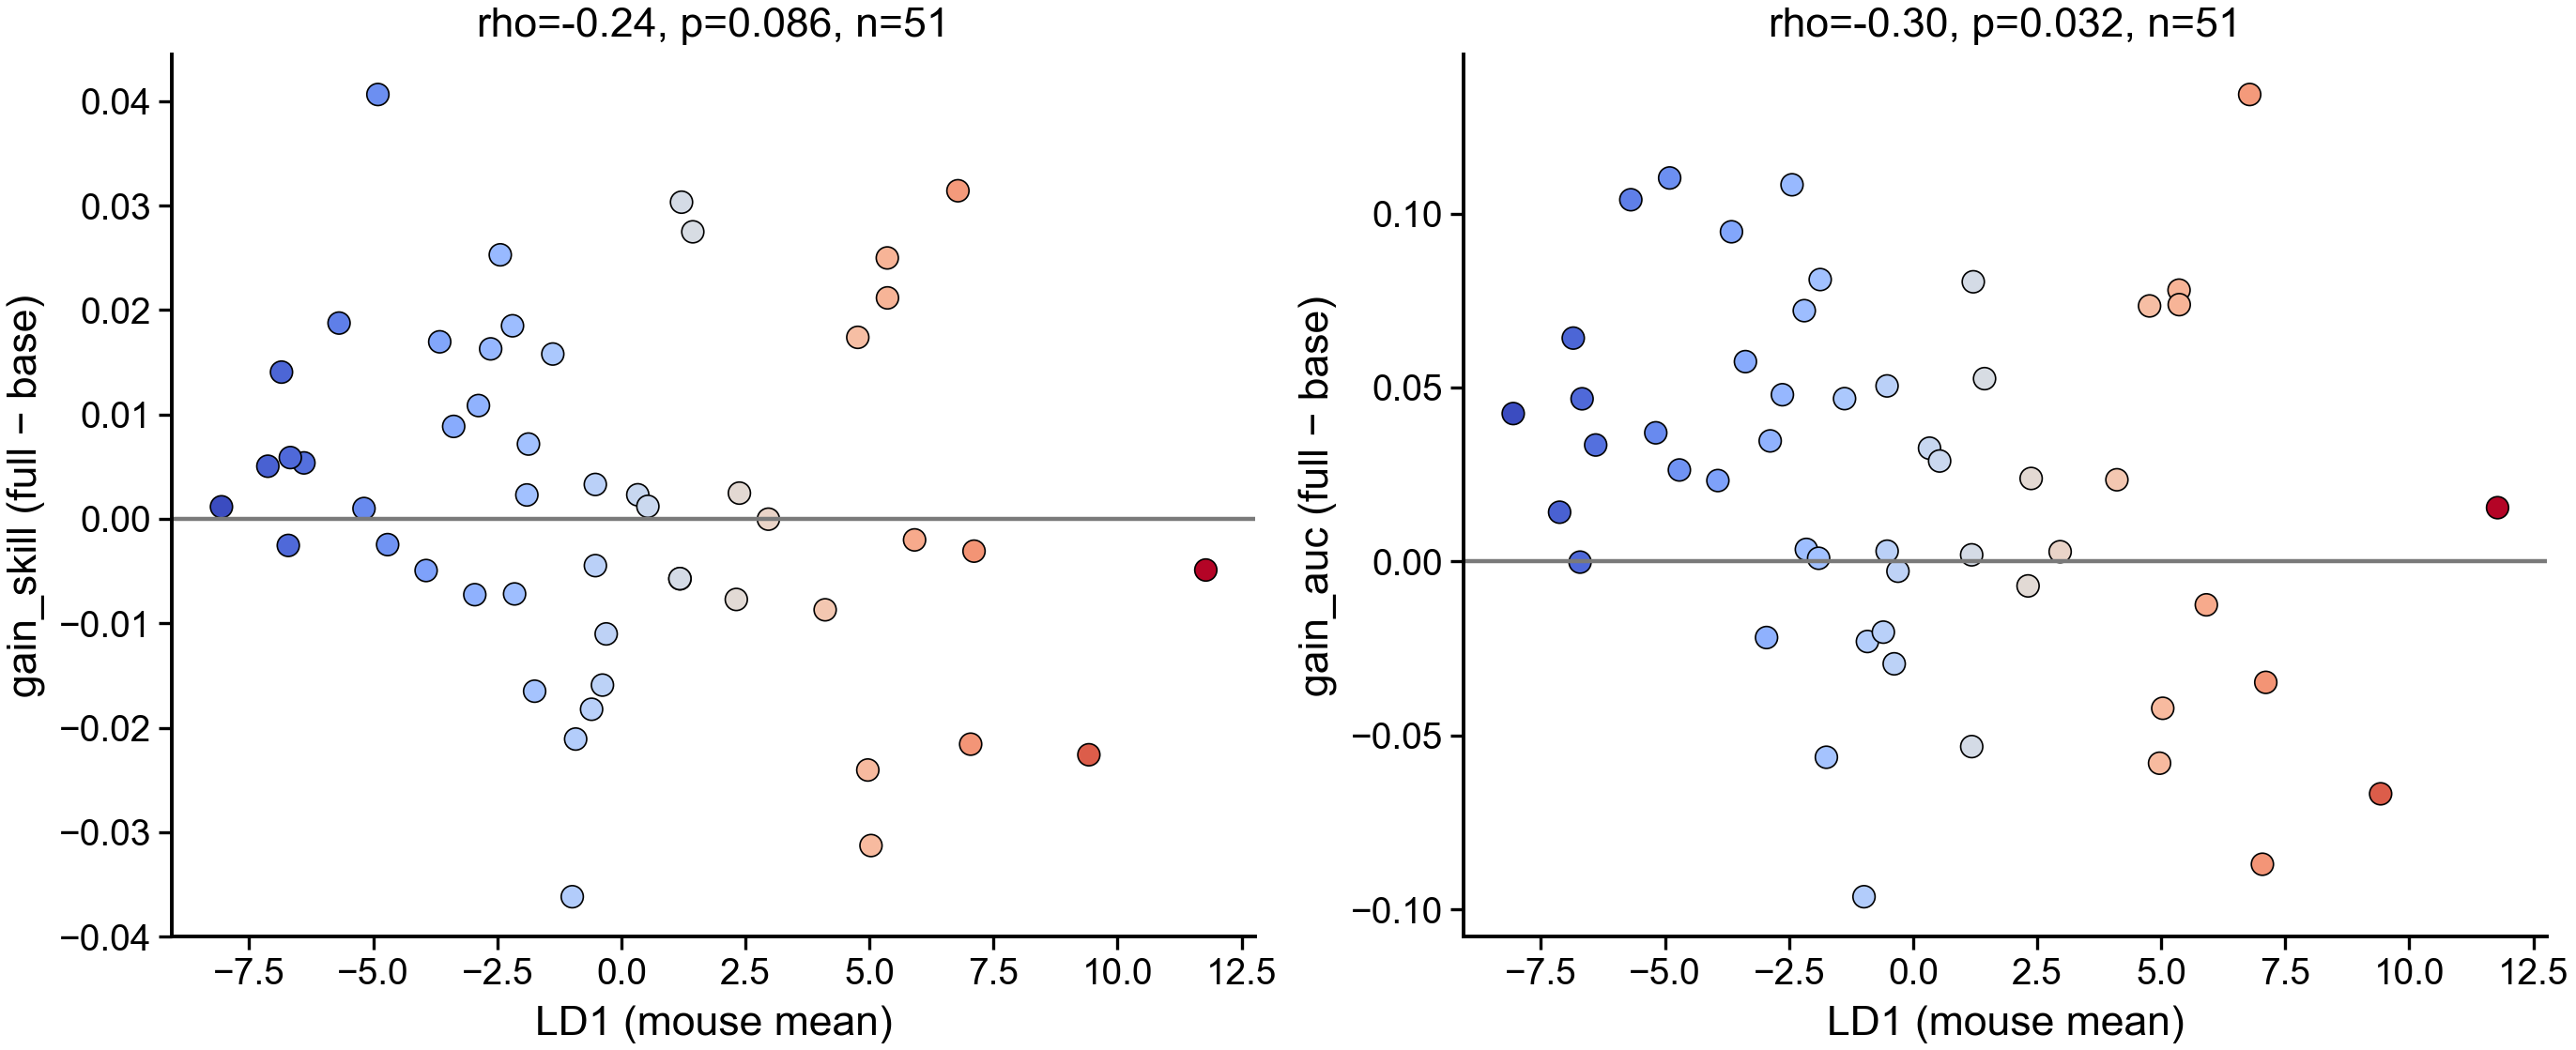

In [12]:
pm = tm.per_unit_scores(y, preds, meta, unit='mouse_name', min_events=10)
print(f'{len(pm)} mice with >= 10 events')
res = pd.DataFrame([tm.ld1_correlation(pm, c) for c in ['base_skill', 'full_skill', 'gain_skill', 'base_auc', 'full_auc', 'gain_auc']])
print(res.round(4).to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for ax, col in zip(axes, ['gain_skill', 'gain_auc']):
    ax.scatter(pm['lda_1'], pm[col], c=pm['lda_1'], cmap=ps.LD1_CMAP, s=18, edgecolor='k', lw=0.3)
    ax.axhline(0, color=ps.NEUTRAL, lw=0.8)
    r = tm.ld1_correlation(pm, col)
    ax.set_title(f"rho={r['rho']:.2f}, p={r['p']:.3f}, n={r['n']}", fontsize=8)
    ax.set_xlabel('LD1 (mouse mean)'); ax.set_ylabel(f'{col} (full − base)')
fig.tight_layout(); plt.show()

In [13]:
inter_summary, inter_mouse, inter_coefs = tm.ld1_interaction(Xb, Xs, y, meta, cv=CV, n_splits=N_SPLITS)
print('held-out, pooled:')
print(pd.DataFrame({k: inter_summary[k] for k in ['full', 'with_ld1_interaction']}).T[['auc', 'll_skill']].round(4))
print(f"\nper mouse Δ log loss (interaction − full): median {inter_summary['median_mouse_d_logloss']:.5f}, "
      f"{inter_summary['frac_mice_improved']:.0%} of mice improved, Wilcoxon p = {inter_summary['wilcoxon_p']:.3g}")
print('\nlargest (syllable × LD1) weights, consistent in sign across folds:')
print(inter_coefs[inter_coefs['sign_agreement'] == 1].reindex(
    inter_coefs['mean'].abs().sort_values(ascending=False).index).dropna().head(12).round(3))

held-out, pooled:
                         auc  ll_skill
full                  0.6270    0.0193
with_ld1_interaction  0.6266    0.0201

per mouse Δ log loss (interaction − full): median -0.00030, 57% of mice improved, Wilcoxon p = 0.483

largest (syllable × LD1) weights, consistent in sign across folds:
                                     mean     sd  sign_agreement
t|Quiescence|paw_modL x LD1        -0.061  0.020             1.0
t|Quiescence|paw_slow x LD1         0.044  0.020             1.0
t-2|Choice|paw_vfast x LD1          0.042  0.012             1.0
t|Pre-quiescence|whisk x LD1        0.038  0.008             1.0
t-1|Choice|paw_fastL x LD1          0.032  0.003             1.0
t|Pre-quiescence|paw_modR x LD1     0.031  0.015             1.0
t-2|Pre-quiescence|paw_fastL x LD1 -0.031  0.012             1.0
t|Pre-quiescence|paw_slow x LD1    -0.031  0.011             1.0
t-1|ITI|paw_fastR x LD1            -0.030  0.009             1.0
t-1|Pre-quiescence|paw_mod x LD1   -0.029  0.

In [14]:
skill_T, auc_T, bin_coefs = tm.transfer_matrix(Xb, Xs, y, meta, n_bins=N_LD1_BINS, n_splits=N_SPLITS)
bins = tm.ld1_bins(meta, N_LD1_BINS)
print('mice per LD1 bin:', pd.Series(bins).groupby(meta['mouse_name'].to_numpy()).first().value_counts().sort_index().to_dict())
print('\nheld-out log-loss skill (rows = trained on, cols = tested on):'); print(skill_T.round(4))
print('\nheld-out AUC:'); print(auc_T.round(3))
syl_rows = [c for c in bin_coefs.index if '|' in c]
print('\ncorrelation of syllable weights between LD1 bins:')
print(bin_coefs.loc[syl_rows].corr().round(2))

mice per LD1 bin: {0: 19, 1: 18, 2: 19}

held-out log-loss skill (rows = trained on, cols = tested on):
             test bin 0  test bin 1  test bin 2
train bin 0      0.0191      0.0097      0.0147
train bin 1      0.0136      0.0039      0.0098
train bin 2      0.0139      0.0086      0.0053

held-out AUC:
             test bin 0  test bin 1  test bin 2
train bin 0       0.608       0.593       0.594
train bin 1       0.607       0.569       0.586
train bin 2       0.602       0.574       0.496

correlation of syllable weights between LD1 bins:
           LD1 bin 0  LD1 bin 1  LD1 bin 2
LD1 bin 0       1.00       0.25       0.22
LD1 bin 1       0.25       1.00       0.05
LD1 bin 2       0.22       0.05       1.00


## Notes / next steps

* **States**: `STATE_SOURCE='all_k', K=3` (or 4) splits the disengaged state; with K>2 `reengage` means leaving the current non-engaged state, which may be into another non-engaged state. Worth running because K=2 is not the CV-preferred model on these data.
* **Timing tolerance**: the smoothed posterior places a switch only to within a few trials; `HORIZON` > 1 asks "will it switch soon" instead of "on this exact trial".
* **Feature set**: `FEATURE_SET='joint'` uses the 32 joint syllables (4× more features; expect more shrinkage).
* **Raw vs centred**: `CENTER=None` lets session-level usage in — then LD1 and the features share information by construction.
* **Lab**: LD1 is lab-confounded; before interpreting section 4, repeat with lab-centred LD1.